# LAB 1 — Nhập môn Tối ưu hóa — Lại Trần Đình Nguyên


## 0. Chuẩn bị môi trường

In [1]:
# Import các thư viện cần thiết cho toàn bộ notebook
import numpy as np
import matplotlib.pyplot as plt
import time

# Kiểm tra phiên bản NumPy đang sử dụng
print("NumPy version:", np.__version__)

NumPy version: 2.1.3


## 1. Bài thực hành 1 — Hàm mục tiêu một biến

Cho hàm mục tiêu: $f(x) = (x-2)^2 + 1$

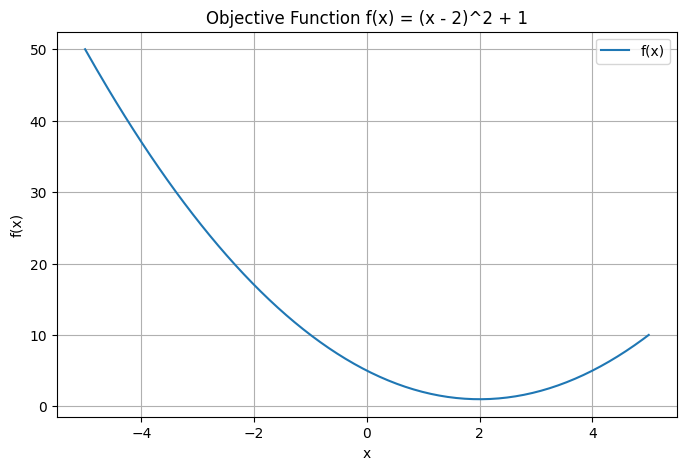

In [2]:
# Yêu cầu 1: tạo 200 giá trị x trong khoảng [-5, 5]
x = np.linspace(-5, 5, 200)

# Yêu cầu 2: tính giá trị objective tương ứng với từng x
f = (x - 2)**2 + 1

# Yêu cầu 3: vẽ đồ thị hàm mục tiêu
plt.figure(figsize=(8, 5))
plt.plot(x, f, label="f(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Objective Function f(x) = (x - 2)^2 + 1")
plt.grid(True)
plt.legend()
plt.show()

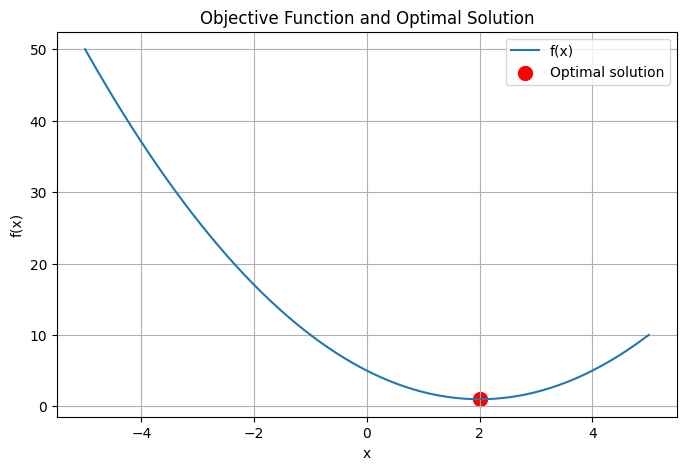

Nghiem toi uu: x* = 2, f* = 1


In [3]:
# Yêu cầu 4: đánh dấu nghiệm tối ưu x* = 2, f* = 1
x_opt = 2
f_opt = 1

plt.figure(figsize=(8, 5))
plt.plot(x, f, label="f(x)")
plt.scatter(x_opt, f_opt, s=100, color="red", label="Optimal solution")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Objective Function and Optimal Solution")
plt.grid(True)
plt.legend()
plt.show()

print(f"Nghiem toi uu: x* = {x_opt}, f* = {f_opt}")


1. Hàm đạt giá trị nhỏ nhất tại **x = 2**.
2. Giá trị tối ưu của hàm là **f(x\*) = 1**.
3. Khi x đi xa khỏi x = 2 (về cả hai phía), giá trị f(x) **tăng dần** theo dạng parabol (tăng theo bình phương khoảng cách tới 2).
4. Hàm này có dạng parabol lồi lên trên (một cực tiểu toàn cục duy nhất), do đó đây là **hàm lồi**.

## 2. Bài thực hành 2 — Hàm mục tiêu hai biến

Cho hàm mục tiêu: $f(x,y) = (x-1)^2 + 2(y+2)^2$

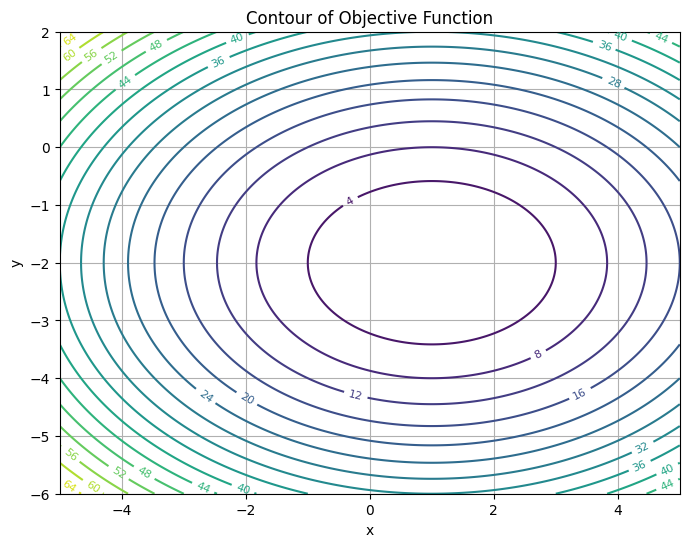

In [4]:
# Bước 1: tạo miền giá trị cho x và y
x2 = np.linspace(-5, 5, 200)
y2 = np.linspace(-6, 2, 200)

# Bước 2: tạo lưới Meshgrid từ hai miền giá trị
X2, Y2 = np.meshgrid(x2, y2)

# Bước 3: tính giá trị objective trên toàn lưới
Z2 = (X2 - 1)**2 + 2*(Y2 + 2)**2

# Bước 4: vẽ Contour Plot
plt.figure(figsize=(8, 6))
contour = plt.contour(X2, Y2, Z2, levels=20)
plt.clabel(contour, inline=True, fontsize=8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour of Objective Function")
plt.grid(True)
plt.show()

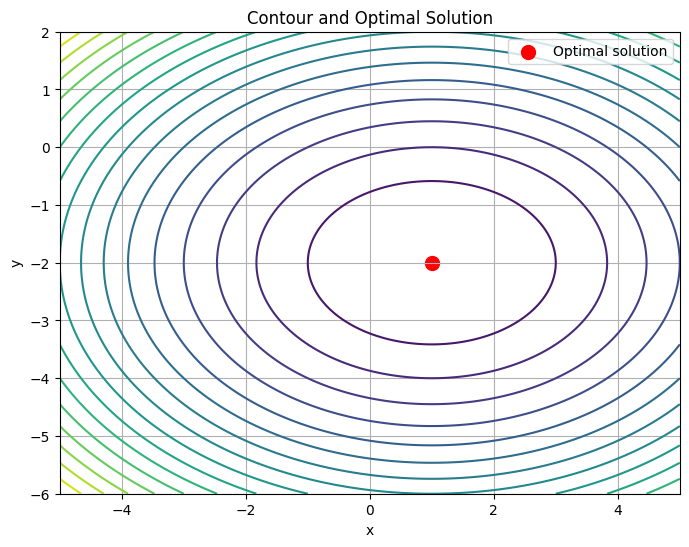

Nghiem toi uu: (x*, y*) = (1, -2), f(1,-2) = 0


In [5]:
# Bước 5: đánh dấu nghiệm tối ưu (x*, y*) = (1, -2)
plt.figure(figsize=(8, 6))
contour = plt.contour(X2, Y2, Z2, levels=20)
plt.scatter(1, -2, s=100, color="red", label="Optimal solution")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour and Optimal Solution")
plt.grid(True)
plt.legend()
plt.show()

print("Nghiem toi uu: (x*, y*) = (1, -2), f(1,-2) =", (1-1)**2 + 2*(-2+2)**2)


1. Các đường contour biểu diễn tập hợp các điểm (x, y) có **cùng giá trị hàm mục tiêu**.
2. Nghiệm tối ưu nằm tại tâm của các đường contour, tại **(x, y) = (1, -2)**.
3. Giá trị **f(1, -2) = 0**.
4. Các đường contour có dạng ellipse vì hàm là tổng hai bình phương với hệ số khác nhau (1 và 2) trên hai trục — hệ số bậc hai không bằng nhau khiến hình tròn bị "kéo dãn" thành ellipse.

## 3. Bài thực hành 3 — Mô hình hóa bài toán phân bổ GPU

Một trung tâm AI có **8 GPU** và hai loại công việc (Job A, Job B). Mỗi GPU chạy Job A tạo **5** đơn vị hiệu năng; mỗi GPU chạy Job B tạo **8** đơn vị hiệu năng. Mục tiêu: tối đa hóa tổng hiệu năng.

**Mô hình toán học hoàn chỉnh:**

$$\max P(x_A, x_B) = 5x_A + 8x_B$$
$$\text{s.t. } x_A + x_B \le 8,\quad x_A, x_B \in \mathbb{Z}_{\ge 0}$$

**Bảng xác định Decision Variables — Objective Function — Constraints:**

| Thành phần | Biểu diễn | Ý nghĩa |
|---|---|---|
| Biến quyết định | $x_A$ | Số GPU cấp cho Job A |
| Biến quyết định | $x_B$ | Số GPU cấp cho Job B |
| Objective | $5x_A + 8x_B$ | Tổng hiệu năng |
| Constraint | $x_A + x_B \le 8$ | Tổng GPU tối đa |
| Constraint | $x_A, x_B \ge 0$ | Không cấp số GPU âm |
| Constraint | $x_A, x_B \in \mathbb{Z}$ | GPU là số nguyên |

## 4. Bài thực hành 4 — Giải bài toán GPU bằng Brute Force

In [6]:
# Bước 1: liệt kê tất cả nghiệm khả thi bằng cách thử x_A, x_B từ 0 đến 8
feasible_solutions = []
for x_A in range(9):
    for x_B in range(9):
        if x_A + x_B <= 8:                 # kiểm tra ràng buộc tổng GPU
            performance = 5*x_A + 8*x_B    # tính giá trị hàm mục tiêu
            feasible_solutions.append((x_A, x_B, performance))

# Bước 2: hiển thị toàn bộ nghiệm khả thi
print("x_A | x_B | Performance")
for solution in feasible_solutions:
    print(solution)
print("\nSo luong nghiem kha thi:", len(feasible_solutions))

x_A | x_B | Performance
(0, 0, 0)
(0, 1, 8)
(0, 2, 16)
(0, 3, 24)
(0, 4, 32)
(0, 5, 40)
(0, 6, 48)
(0, 7, 56)
(0, 8, 64)
(1, 0, 5)
(1, 1, 13)
(1, 2, 21)
(1, 3, 29)
(1, 4, 37)
(1, 5, 45)
(1, 6, 53)
(1, 7, 61)
(2, 0, 10)
(2, 1, 18)
(2, 2, 26)
(2, 3, 34)
(2, 4, 42)
(2, 5, 50)
(2, 6, 58)
(3, 0, 15)
(3, 1, 23)
(3, 2, 31)
(3, 3, 39)
(3, 4, 47)
(3, 5, 55)
(4, 0, 20)
(4, 1, 28)
(4, 2, 36)
(4, 3, 44)
(4, 4, 52)
(5, 0, 25)
(5, 1, 33)
(5, 2, 41)
(5, 3, 49)
(6, 0, 30)
(6, 1, 38)
(6, 2, 46)
(7, 0, 35)
(7, 1, 43)
(8, 0, 40)

So luong nghiem kha thi: 45


In [7]:
# Bước 3: tìm nghiệm tối ưu bằng cách so sánh performance của từng nghiệm khả thi
best_solution = None
best_value = -np.inf
for x_A in range(9):
    for x_B in range(9):
        if x_A + x_B <= 8:
            performance = 5*x_A + 8*x_B
            if performance > best_value:   # cập nhật nếu tìm được nghiệm tốt hơn
                best_value = performance
                best_solution = (x_A, x_B)

print("Best solution (x_A, x_B):", best_solution)
print("Best objective:", best_value)

Best solution (x_A, x_B): (0, 8)
Best objective: 64


**Bước 4 — Giải thích kết quả:** nghiệm tối ưu là $x_A^* = 0$, $x_B^* = 8$, $P^* = 64$. Vì Job B tạo ra hiệu năng/GPU cao hơn (8 so với 5 của Job A), nên để tối đa hóa tổng hiệu năng, thuật toán dồn toàn bộ 8 GPU cho Job B — kết quả này hoàn toàn hợp lý xét theo hiệu năng đơn vị của từng loại job.

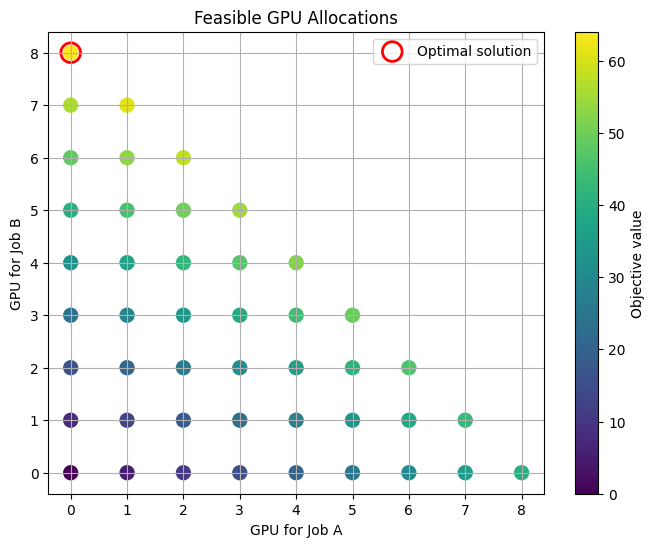

In [8]:
# Bước 5: trực quan hóa toàn bộ các nghiệm khả thi
XA = [s[0] for s in feasible_solutions]
XB = [s[1] for s in feasible_solutions]
P  = [s[2] for s in feasible_solutions]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(XA, XB, c=P, s=100, cmap="viridis")
plt.colorbar(scatter, label="Objective value")
plt.scatter(best_solution[0], best_solution[1], s=200, facecolors='none',
            edgecolors='red', linewidths=2, label="Optimal solution")
plt.xlabel("GPU for Job A")
plt.ylabel("GPU for Job B")
plt.title("Feasible GPU Allocations")
plt.grid(True)
plt.legend()
plt.show()

## 5. Bài tập 1 — Hàm mục tiêu một biến không lồi: Grid Search và độ phân giải

Cho hàm mục tiêu: $f(x) = (x^2 - 4)^2 + 0.5x,\; x \in [-3, 3]$

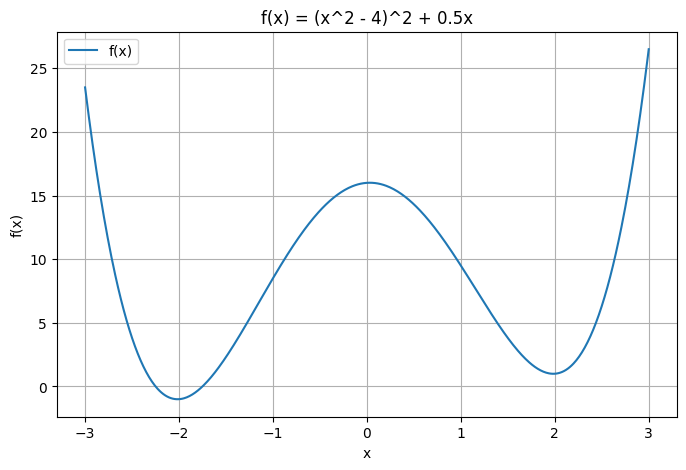

In [9]:
# Định nghĩa hàm mục tiêu không lồi
def f1(x):
    return (x**2 - 4)**2 + 0.5 * x

# Yêu cầu 1: vẽ đồ thị với ít nhất 600 điểm trên [-3, 3]
x_plot = np.linspace(-3, 3, 600)
f_plot = f1(x_plot)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, f_plot, label="f(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) = (x^2 - 4)^2 + 0.5x")
plt.grid(True)
plt.legend()
plt.show()

**Nhận xét tính lồi:** đồ thị cho thấy hàm có **hai đáy cực tiểu địa phương** (gần x = -2 và x = 2), do đó **hàm không lồi trên toàn miền [-3, 3]** (một hàm lồi chỉ có tối đa một cực tiểu).

In [10]:
# Yêu cầu 2-3: Grid Search với ba bước lưới khác nhau, không dùng đạo hàm
steps = [0.5, 0.1, 0.01]
results = []

for step in steps:
    start_time = time.time()
    xs = np.arange(-3, 3 + step, step)   # sinh lưới điểm với bước step
    fs = f1(xs)                          # đánh giá hàm mục tiêu tại từng điểm
    idx_min = np.argmin(fs)              # tìm chỉ số điểm có f nhỏ nhất
    x_hat = xs[idx_min]
    f_hat = fs[idx_min]
    runtime = time.time() - start_time
    results.append((step, len(xs), x_hat, f_hat, runtime))

print(f"{'Delta x':>10} | {'So lan danh gia':>16} | {'x_hat':>10} | {'f(x_hat)':>12} | {'Runtime (s)':>12}")
for step, n_evals, x_hat, f_hat, runtime in results:
    print(f"{step:>10} | {n_evals:>16} | {x_hat:>10.4f} | {f_hat:>12.6f} | {runtime:>12.6f}")

   Delta x |  So lan danh gia |      x_hat |     f(x_hat) |  Runtime (s)
       0.5 |               13 |    -2.0000 |    -1.000000 |     0.000696
       0.1 |               61 |    -2.0000 |    -1.000000 |     0.000137
      0.01 |              601 |    -2.0200 |    -1.003536 |     0.000036


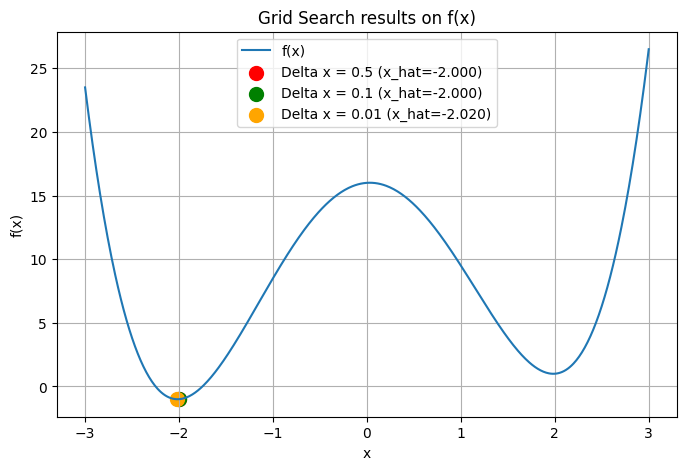

In [11]:
# Yêu cầu 4: đánh dấu nghiệm tốt nhất của từng lưới trên cùng một đồ thị
plt.figure(figsize=(8, 5))
plt.plot(x_plot, f_plot, label="f(x)")
colors = ["red", "green", "orange"]
for (step, n_evals, x_hat, f_hat, runtime), c in zip(results, colors):
    plt.scatter(x_hat, f_hat, s=100, color=c,
                label=f"Delta x = {step} (x_hat={x_hat:.3f})")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Grid Search results on f(x)")
plt.grid(True)
plt.legend()
plt.show()


5. Lưới càng mịn (Δx càng nhỏ) thì số điểm cần đánh giá càng nhiều (13 → 61 → 601 điểm), làm runtime tăng, nhưng khả năng bắt được vị trí cực tiểu chính xác hơn vì không bỏ sót các dao động nhỏ của hàm số. Lưới thô tính nhanh nhưng dễ bỏ qua cực tiểu toàn cục nếu nó nằm giữa hai điểm lưới.
6. Đồ thị cho thấy hàm có nhiều hơn một cực tiểu địa phương (local minima). Vì Grid Search quét toàn bộ miền giá trị thay vì xuất phát từ một điểm rồi đi theo hướng giảm dần, nó không phụ thuộc vào điểm khởi tạo và ít bị "mắc kẹt" ở cực tiểu địa phương hơn các phương pháp local search như Gradient Descent, dù phải đánh đổi bằng chi phí tính toán lớn hơn khi không gian tìm kiếm tăng.

## 6. Bài tập 2 — Hàm mục tiêu hai biến

Cho hàm mục tiêu: $f(x,y) = 2(x-2)^2 + (y-1)^2$

In [12]:
# Bước 1-2: tạo Meshgrid và tính objective
def f2(x, y):
    return 2 * (x - 2)**2 + (y - 1)**2

x3 = np.linspace(-2, 6, 200)
y3 = np.linspace(-4, 6, 200)
X3, Y3 = np.meshgrid(x3, y3)
Z3 = f2(X3, Y3)

# Bước 4: nghiệm tối ưu xác định bằng phân tích (đạo hàm riêng = 0)
x_opt2, y_opt2 = 2, 1
f_opt2 = f2(x_opt2, y_opt2)
print(f"Nghiem toi uu (phan tich): x* = {x_opt2}, y* = {y_opt2}, f(x*,y*) = {f_opt2}")

Nghiem toi uu (phan tich): x* = 2, y* = 1, f(x*,y*) = 0


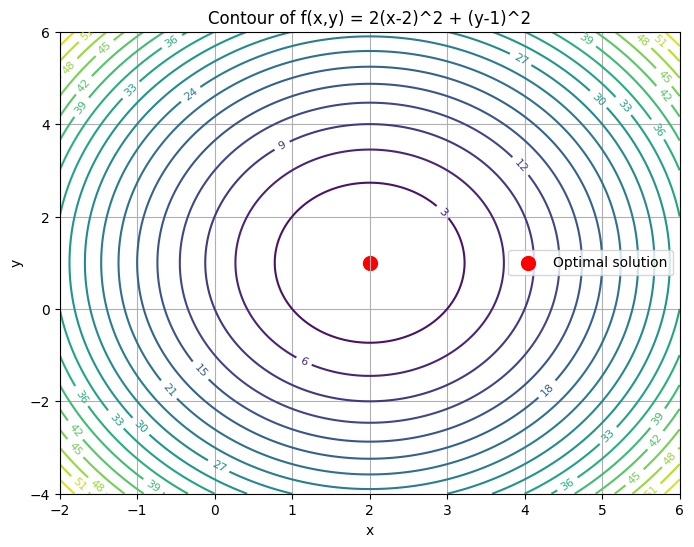

In [13]:
# Bước 3 + 5: vẽ Contour Plot và đánh dấu nghiệm tối ưu
plt.figure(figsize=(8, 6))
contour = plt.contour(X3, Y3, Z3, levels=20)
plt.clabel(contour, inline=True, fontsize=8)
plt.scatter(x_opt2, y_opt2, s=100, color="red", label="Optimal solution")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour of f(x,y) = 2(x-2)^2 + (y-1)^2")
plt.grid(True)
plt.legend()
plt.show()

**Nhận xét (Bước 6):** hàm $f(x,y) = 2(x-2)^2 + (y-1)^2$ có hệ số bậc hai theo x (=2) lớn hơn theo y (=1), nên contour là các ellipse **nén theo trục x, kéo dài theo trục y** — ngược với hàm $f(x,y) = (x-1)^2 + 2(y+2)^2$ ở Thực hành 2 (nén theo trục y, kéo dài theo trục x, vì hệ số lớn nằm ở thành phần y). Tâm ellipse cũng dịch sang vị trí (2, 1) thay vì (1, -2).

## 7. Bài tập 3 — Bài toán phân bổ GPU mở rộng

Một trung tâm AI có **12 GPU** và ba loại job:

| Job | Hiệu năng/GPU |
|---|---|
| A | 5 |
| B | 8 |
| C | 6 |

Yêu cầu: tổng GPU sử dụng ≤ 12; Job A ít nhất 2 GPU; Job B ít nhất 1 GPU; các biến là số nguyên không âm.

**Bảng xác định Decision Variables — Objective Function — Constraints:**

| Thành phần | Biểu diễn | Ý nghĩa |
|---|---|---|
| Biến quyết định | $x_A$ | Số GPU cấp cho Job A |
| Biến quyết định | $x_B$ | Số GPU cấp cho Job B |
| Biến quyết định | $x_C$ | Số GPU cấp cho Job C |
| Objective | $5x_A + 8x_B + 6x_C$ | Tổng hiệu năng |
| Constraint | $x_A + x_B + x_C \le 12$ | Tổng GPU tối đa |
| Constraint | $x_A \ge 2$ | Job A tối thiểu 2 GPU |
| Constraint | $x_B \ge 1$ | Job B tối thiểu 1 GPU |
| Constraint | $x_A, x_B, x_C \in \mathbb{Z}_{\ge 0}$ | GPU là số nguyên không âm |

**Mô hình toán học hoàn chỉnh:**

$$\max P = 5x_A + 8x_B + 6x_C$$
$$\text{s.t. } x_A + x_B + x_C \le 12,\; x_A \ge 2,\; x_B \ge 1,\; x_A,x_B,x_C \in \mathbb{Z}_{\ge 0}$$

In [14]:
# Brute Force: liệt kê tất cả nghiệm khả thi thỏa các ràng buộc
TOTAL_GPU = 12
PERF_A, PERF_B, PERF_C = 5, 8, 6
MIN_A, MIN_B, MIN_C = 2, 1, 0

feasible_solutions3 = []
for x_A in range(MIN_A, TOTAL_GPU + 1):
    for x_B in range(MIN_B, TOTAL_GPU + 1):
        for x_C in range(MIN_C, TOTAL_GPU + 1):
            if x_A + x_B + x_C <= TOTAL_GPU:           # ràng buộc tổng GPU
                performance = PERF_A*x_A + PERF_B*x_B + PERF_C*x_C
                feasible_solutions3.append((x_A, x_B, x_C, performance))

print("So luong nghiem kha thi:", len(feasible_solutions3))
print("5 nghiem dau tien:", feasible_solutions3[:5])

So luong nghiem kha thi: 220
5 nghiem dau tien: [(2, 1, 0, 18), (2, 1, 1, 24), (2, 1, 2, 30), (2, 1, 3, 36), (2, 1, 4, 42)]


In [15]:
# Tìm nghiệm tối ưu trong tập nghiệm khả thi
best_solution3 = None
best_value3 = -np.inf
for x_A, x_B, x_C, performance in feasible_solutions3:
    if performance > best_value3:
        best_value3 = performance
        best_solution3 = (x_A, x_B, x_C)

print("Best solution (x_A, x_B, x_C):", best_solution3)
print("Best objective (performance):", best_value3)

Best solution (x_A, x_B, x_C): (2, 10, 0)
Best objective (performance): 90


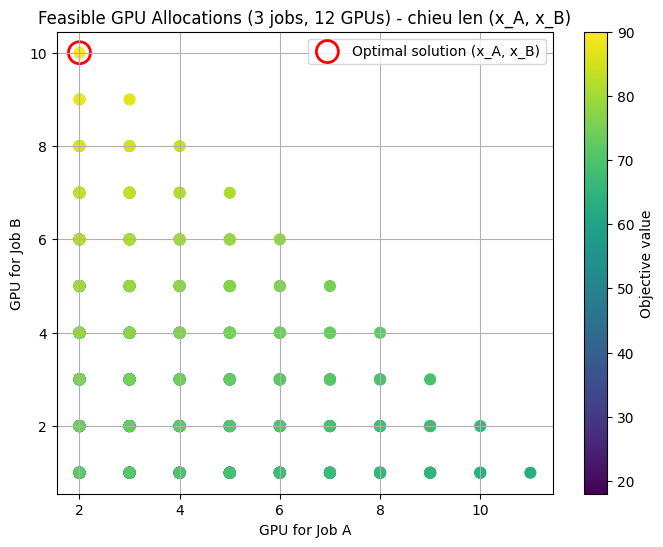

In [16]:
# Trực quan hóa: chiếu các nghiệm khả thi lên mặt phẳng (x_A, x_B),
# màu thể hiện giá trị objective, kích thước điểm không đổi
XA3 = [s[0] for s in feasible_solutions3]
XB3 = [s[1] for s in feasible_solutions3]
P3  = [s[3] for s in feasible_solutions3]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(XA3, XB3, c=P3, s=60, cmap="viridis")
plt.colorbar(scatter, label="Objective value")
plt.scatter(best_solution3[0], best_solution3[1], s=250, facecolors='none',
            edgecolors='red', linewidths=2, label="Optimal solution (x_A, x_B)")
plt.xlabel("GPU for Job A")
plt.ylabel("GPU for Job B")
plt.title("Feasible GPU Allocations (3 jobs, 12 GPUs) - chieu len (x_A, x_B)")
plt.grid(True)
plt.legend()
plt.show()

**Nhận xét:** nghiệm tối ưu tìm được là $(x_A, x_B, x_C) = (2, 10, 0)$ với $P^* = 90$. Vì Job B có hiệu năng/GPU cao nhất (8), sau khi cấp đủ số GPU tối thiểu bắt buộc cho Job A (2 GPU), toàn bộ số GPU còn lại được dồn hết cho Job B để tối đa hóa tổng hiệu năng, không còn GPU nào phân bổ cho Job C (hiệu năng thấp hơn Job B).

## 8. Bài tập 4 — Phân tích độ phức tạp của Brute Force

In [17]:
# Giả sử mỗi biến có k = 10 giá trị có thể lựa chọn
k = 10
n_values = [1, 2, 3, 5, 8, 10]

print(f"{'So bien n':>10} | {'So to hop k^n':>20}")
for n in n_values:
    n_combinations = k ** n
    print(f"{n:>10} | {n_combinations:>20,}")

 So bien n |        So to hop k^n
         1 |                   10
         2 |                  100
         3 |                1,000
         5 |              100,000
         8 |          100,000,000
        10 |       10,000,000,000


**Nhận xét :**
1. Khi số biến n tăng, số nghiệm cần kiểm tra $k^n$ tăng theo hàm mũ chứ không phải tuyến tính — chỉ cần tăng thêm vài biến là số tổ hợp đã nhảy vọt từ hàng trăm lên hàng tỷ (từ $10^1=10$ đến $10^{10}=10{,}000{,}000{,}000$).
2. Với bài toán lớn (nhiều biến hoặc miền giá trị rộng), Brute Force **không còn khả thi** về mặt thời gian và bộ nhớ, vì số phép tính vượt quá khả năng xử lý của máy tính trong thời gian hợp lý.
3. Các thuật toán tối ưu hóa (Gradient Descent, thuật toán tiến hóa, quy hoạch tuyến tính, ...) là **cần thiết** vì chúng khai thác cấu trúc toán học của bài toán (đạo hàm, độ lồi, ràng buộc tuyến tính) để tìm nghiệm tốt mà không cần liệt kê toàn bộ không gian tìm kiếm.
4. Trong Machine Learning, mô hình có thể có hàng nghìn đến hàng tỷ tham số, nên Brute Force **hoàn toàn không thể áp dụng**; thay vào đó người ta dùng các phương pháp tối ưu dựa trên đạo hàm (như Gradient Descent và các biến thể của nó) để cập nhật tham số hiệu quả hơn rất nhiều.

## 9. Nhận xét tổng kết về hạn chế của Brute Force

Brute Force chắc chắn tìm ra nghiệm tối ưu vì nó thử qua hết mọi khả năng, nhưng đổi lại số phép tính tăng rất nhanh theo kiểu hàm mũ (k^n) khi số biến tăng. Với bài toán GPU ở trên (8-12 GPU, 2-3 job) thì không gian nghiệm còn nhỏ nên chạy gần như tức thì và cho kết quả đúng tuyệt đối. Nhưng chỉ cần tăng lên vài chục biến, hoặc biến nhận giá trị liên tục thay vì rời rạc, thì số tổ hợp cần kiểm tra sẽ lớn đến mức máy tính không thể chạy nổi trong thời gian chấp nhận được.

Một hạn chế nữa là Brute Force không quan tâm gì đến "hình dạng" của bài toán — dù hàm mục tiêu có lồi, có đạo hàm đẹp hay ràng buộc tuyến tính, nó vẫn duyệt y như một bài toán bất kỳ, nên rất lãng phí. Điểm hay ho duy nhất là nó dễ hiểu, dễ code, và cho kết quả tin cậy tuyệt đối trên bài toán nhỏ, rời rạc — đó cũng là lý do nó phù hợp để học nhập môn, trước khi qua các thuật toán mạnh hơn như Gradient Descent hay Linear Programming ở các Lab sau.